# Лабораторная лабора №5 - Проведение исследований с градиентным бустингом

### Подготовка

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sklearn
import keras
import nltk
import pandas as pd
import numpy as np
import re
import torch

from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForMaskedLM
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/ai_course/dataset.xlsx")
df.to_csv("dataset.csv", index = False)
df

,oid,text,category
0,749208109,СПОЧНО СООБЩЕСТВО ПРОДАЕТСЯ ЗА 1300Р ЗА ПОКУПК...,esport
1,749208109,Пусть это побудет здесь БорьбаВпрямомЭфире How...,esport
2,749208109,Раздача пиздюлей от Мунсунга. HowToFtokenoid Б...,esport
3,749208109,Не знаю как вам но мне стилистика нравится пус...,esport
4,749208109,Скриншоты из новой главы. Тэхунчика показали и...,esport
...,...,...,...
53193,910636962,8 битная буря снова накрыла пикселями автомоби...,autosport
53194,669736851,Ира Сидоркова объясняет как сказалась на ее ма...,autosport
53195,558919241,24 я ракетка мира хорват Марин Чилич обыграл и...,tennis
53196,776944963,Стал известен календарь мужской сборной России...,volleyball


In [ ]:
df_reg = pd.read_csv("/content/drive/MyDrive/ai_course/train.csv")
df_reg

,cow_id,milk_yield_kg,feed_energy_eke,feed_crude_protein_g,sugar_protein_ratio,breed,pasture_type,sire_breed,milk_fat_pct,milk_protein_pct,milk_taste_label,age_group
0,488,6005,13.5,1842,0.940,РефлешнСоверинг,Равнинное,Айдиал,3.62,3.073,не вкусно,более_2_лет
1,422,5982,13.8,1722,0.890,РефлешнСоверинг,Холмистое,Айдиал,3.61,3.073,не вкусно,более_2_лет
2,105,5700,14.4,1934,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.57,3.079,вкусно,более_2_лет
3,115,5412,12.1,1924,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.57,3.071,не вкусно,менее_2_лет
4,350,6171,15.3,1966,0.940,РефлешнСоверинг,Равнинное,Соверин,3.73,3.076,вкусно,более_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
502,72,5809,13.5,2093,0.895,РефлешнСоверинг,Равнинные,Айдиалл,3.61,3.079,не вкусно,более_2_лет
503,107,5417,13.2,1848,0.890,Вис Бик Айдиал,Холмистое,Соверин,3.57,3.076,вкусно,менее_2_лет
504,271,6597,14.2,2204,0.950,РефлешнСоверинг,Равнинное,Соверин,3.74,3.079,не вкусно,более_2_лет
505,436,6054,15.7,1859,0.940,РефлешнСоверинг,Холмистое,Соверин,3.71,3.080,вкусно,более_2_лет


## 2. Создание бейзлайна и оценка качества

### Бейзлайн классификация

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53198 entries, 0 to 53197
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   oid       53198 non-null  int64 
 1   text      53198 non-null  object
 2   category  53198 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
RANDOM_STATE = 42

TEXT_COL = "text"
LABEL_COL = "category"

In [ ]:
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
df

,oid,text,category
0,749208109,СПОЧНО СООБЩЕСТВО ПРОДАЕТСЯ ЗА 1300Р ЗА ПОКУПК...,esport
1,749208109,Пусть это побудет здесь БорьбаВпрямомЭфире How...,esport
2,749208109,Раздача пиздюлей от Мунсунга. HowToFtokenoid Б...,esport
3,749208109,Не знаю как вам но мне стилистика нравится пус...,esport
4,749208109,Скриншоты из новой главы. Тэхунчика показали и...,esport
...,...,...,...
53193,910636962,8 битная буря снова накрыла пикселями автомоби...,autosport
53194,669736851,Ира Сидоркова объясняет как сказалась на ее ма...,autosport
53195,558919241,24 я ракетка мира хорват Марин Чилич обыграл и...,tennis
53196,776944963,Стал известен календарь мужской сборной России...,volleyball


In [ ]:
le = LabelEncoder()
y = le.fit_transform(df[LABEL_COL].astype(str))
X = df[TEXT_COL].astype(str)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

У меня произошла проблема с ОЗУ, поэтому я сильно обрезала датасет (зато классы теперь сбалансированные)

Детали в самом конце

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import HistGradientBoostingClassifier

classification = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=30_000,
        sublinear_tf=True,
        norm="l2"
    )),
    ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ("gb", HistGradientBoostingClassifier(
        random_state=42,
        max_depth=3,
        max_iter=30,
        learning_rate=0.1,
        verbose=1
    ))
])

classification.fit(X_train_resampled['text'], y_train_resampled)

Binning 1.872 GB of training data: 69.283 s
Fitting gradient boosted rounds:
Fit 390 trees in 559.598 s, (2227 total leaves)
Time spent computing histograms: 476.784s
Time spent finding best splits:  11.640s
Time spent applying splits:      0.184s
Time spent predicting:           0.022s


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('to_dense',
                 FunctionTransformer(accept_sparse=True,
                                     func=<function <lambda> at 0x79560c38fce0>)),
                ('gb',
                 HistGradientBoostingClassifier(max_depth=3, max_iter=30,
                                                random_state=42, verbose=1))])

In [ ]:
from sklearn.metrics import classification_report

y_pred_resampled = classification.predict(X_test)

print(classification_report(y_test, y_pred_resampled, target_names=le.classes_))

              precision    recall  f1-score   support

   athletics       0.84      0.64      0.73       957
   autosport       0.76      0.62      0.68       630
  basketball       0.80      0.52      0.63       866
  boardgames       0.73      0.71      0.72       910
      esport       0.38      0.51      0.44       902
     extreme       0.27      0.56      0.37       634
    football       0.33      0.62      0.43       852
      hockey       0.60      0.49      0.54       370
martial_arts       0.83      0.49      0.61       852
   motosport       0.86      0.70      0.77       906
      tennis       0.90      0.74      0.81       917
  volleyball       0.78      0.60      0.67       937
winter_sport       0.61      0.56      0.58       907

    accuracy                           0.60     10640
   macro avg       0.67      0.60      0.61     10640
weighted avg       0.68      0.60      0.62     10640



#### Выводы по бейзлайну

Результат очевидно хуже, так как данных сильно меньше, но хотя бы не 50%

### Бейзлайн регрессия

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
RANDOM_STATE=42

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/ai_course/train.csv")
test = pd.read_csv("/content/drive/MyDrive/ai_course/test.csv")
train.head()

,cow_id,milk_yield_kg,feed_energy_eke,feed_crude_protein_g,sugar_protein_ratio,breed,pasture_type,sire_breed,milk_fat_pct,milk_protein_pct,milk_taste_label,age_group
0,488,6005,13.5,1842,0.940,РефлешнСоверинг,Равнинное,Айдиал,3.62,3.073,не вкусно,более_2_лет
1,422,5982,13.8,1722,0.890,РефлешнСоверинг,Холмистое,Айдиал,3.61,3.073,не вкусно,более_2_лет
2,105,5700,14.4,1934,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.57,3.079,вкусно,более_2_лет
3,115,5412,12.1,1924,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.57,3.071,не вкусно,менее_2_лет
4,350,6171,15.3,1966,0.940,РефлешнСоверинг,Равнинное,Соверин,3.73,3.076,вкусно,более_2_лет


In [ ]:
TARGET_COL = "milk_yield_kg"
ID_COL_CANDIDATES = ["cow_id"]

In [ ]:
feature_cols = [c for c in train.columns if c != TARGET_COL]

id_col = next((c for c in ID_COL_CANDIDATES if c in test.columns), None)
if id_col is None:
    test_id = pd.Series(test.index, name="row_id")
else:
    test_id = test[id_col].copy()

In [ ]:
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

Минимальные препроцессинг данных для работы модели

In [ ]:
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

In [ ]:
reg = Pipeline(steps=[
    ("prep", preprocess),
    ("gb", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [ ]:
X = train[feature_cols]
y = train[TARGET_COL].astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [ ]:
reg.fit(X_tr, y_tr)
y_hat = reg.predict(X_te)

mae  = mean_absolute_error(y_te, y_hat)
mse = mean_squared_error(y_te, y_hat)
r2 = r2_score(y_te, y_hat)
print(f"MAE : {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R^2 : {r2:.4f}")

MAE : 516.7219
MSE: 15838605.0413
R^2 : -58.4571


#### Выводы по регрессии

Качество КРАЙНЕ низкое, лин регрессия на бейзлайне давала результаты лучше

## 3. Улучшение бейзлайна

### Классификация

Гипотезы для улучшения:

1. в этот раз использовала версию с эмбеддингами и тоже сокращала, возможно будет лучше считываться семантическая близость

2. Была предварительная балансировка -> recall должен вырасти

3. Подбор гиперараметров должен улучшить качество

Ожидание: F1-score и точность вырастут, особенно для редких классов.

#### Загрузка данных

In [ ]:
import numpy as np
from joblib import load

X_train_embeddings = np.load("/content/drive/MyDrive/ai_course/X_train_embeddings.npy")
X_test_embeddings  = np.load("/content/drive/MyDrive/ai_course/X_test_embeddings.npy")
y_train = np.load("/content/drive/MyDrive/ai_course/y_train.npy")
y_test = np.load("/content/drive/MyDrive/ai_course/y_test.npy")

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 9.9 MB/s eta 0:00:00


#### Обучение модели

In [ ]:
RANDOM_STATE = 42

In [ ]:
import optuna
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, f1_score

In [ ]:
import numpy as np
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler

MAX_PER_CLASS = 600

class_counts = pd.Series(y_train).value_counts()

sampling_strategy = {
    cls: min(cnt, MAX_PER_CLASS)
    for cls, cnt in class_counts.items()
}

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_dummy = np.arange(len(y_train)).reshape(-1, 1)

idx_resampled, y_train_resampled = rus.fit_resample(X_dummy, y_train)
idx_resampled = idx_resampled.flatten()

In [ ]:
X_train_resampled = X_train_embeddings[idx_resampled]

In [ ]:
print(X_train_resampled.shape)
print(y_train_resampled.shape)


(7800, 768)
(7800,)


In [ ]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2),
        "max_iter": trial.suggest_int("max_iter", 50, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 60),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 2.0),
        "random_state": 42
    }

    model = HistGradientBoostingClassifier(**params)

    score = cross_val_score(
        model,
        X_train_resampled,
        y_train_resampled,
        cv=2,
        scoring="accuracy",
        n_jobs=1
    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=3)

print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2025-12-14 15:26:27,936] A new study created in memory with name: no-name-e01b0ff5-ce48-4f47-b98a-296743a25790
[I 2025-12-14 15:29:20,768] Trial 0 finished with value: 0.7557692307692307 and parameters: {'learning_rate': 0.11558849961137817, 'max_iter': 69, 'max_depth': 6, 'min_samples_leaf': 26, 'l2_regularization': 0.8896867061014198}. Best is trial 0 with value: 0.7557692307692307.
[I 2025-12-14 15:31:16,360] Trial 1 finished with value: 0.7698717948717948 and parameters: {'learning_rate': 0.10975557016772755, 'max_iter': 99, 'max_depth': 4, 'min_samples_leaf': 49, 'l2_regularization': 0.4671649398455384}. Best is trial 1 with value: 0.7698717948717948.
[I 2025-12-14 15:32:53,045] Trial 2 finished with value: 0.765 and parameters: {'learning_rate': 0.12203668912522057, 'max_iter': 78, 'max_depth': 4, 'min_samples_leaf': 35, 'l2_regularization': 0.8426556756565047}. Best is trial 1 with value: 0.7698717948717948.


Best params: {'learning_rate': 0.10975557016772755, 'max_iter': 99, 'max_depth': 4, 'min_samples_leaf': 49, 'l2_regularization': 0.4671649398455384}
Best accuracy: 0.7698717948717948


In [ ]:
best_gb = HistGradientBoostingClassifier(
    **study.best_params,
    random_state=42
)

best_gb.fit(X_train_resampled, y_train_resampled)

y_pred_best = best_gb.predict(X_test_embeddings)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       311
           1       0.78      0.76      0.77       302
           2       0.80      0.74      0.77       307
           3       0.90      0.91      0.91       305
           4       0.74      0.81      0.78       314
           5       0.62      0.75      0.68       306
           6       0.81      0.70      0.75       307
           7       0.69      0.75      0.72       301
           8       0.84      0.82      0.83       313
           9       0.87      0.72      0.79       303
          10       0.93      0.88      0.90       317
          11       0.78      0.79      0.79       316
          12       0.79      0.84      0.81       305

    accuracy                           0.79      4007
   macro avg       0.80      0.79      0.80      4007
weighted avg       0.80      0.79      0.80      4007



#### ИТОГ 3 пункта

Метрики на бейзлайне
```
accuracy                           0.60     10640
macro avg       0.67      0.60      0.61     10640
weighted avg       0.68      0.60      0.62     10640
```


Качество действительно сильно возрасло, хотя данных столько же и подбор гиперпараметров был слабый

балансировка классов и использование эмбеддингов улучшили качество классификации за счёт снижения перекоса классов и более информативного представления текста

### Регрессия

Попробуем:

1. Очистка данных даст буст

2. настройка гиперпараметров тоже (особенно n_estimatoe и глубина, лернинг рейт тоже)

3. Уменьшим шанс переобучения


Ожидание: Ошибка (MAE, MSE) снизится

#### Загрузка чистых данных

In [ ]:
X_test = pd.read_csv("/content/drive/MyDrive/ai_course/X_test.csv")
X_train = pd.read_csv("/content/drive/MyDrive/ai_course/X_train.csv")
y_train = pd.read_csv("/content/drive/MyDrive/ai_course/y_train.csv").squeeze()
y_test  = pd.read_csv("/content/drive/MyDrive/ai_course/y_test.csv").squeeze()

#### Обучение

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 11.3 MB/s eta 0:00:00


In [ ]:
RANDOM_STATE=42

In [ ]:
import numpy as np
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)

In [ ]:
def objective_reg(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }

    model_pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("gb", GradientBoostingRegressor(random_state=42, **params))
    ])

    score = cross_val_score(model_pipeline, X_train, y_train, cv=3, scoring='r2').mean()
    return score

In [ ]:
study_reg = optuna.create_study(direction='maximize')
study_reg.optimize(objective_reg, n_trials=20)

print("best params:", study_reg.best_params)
print("Best R2:", study_reg.best_value)

[I 2025-12-14 14:15:23,269] A new study created in memory with name: no-name-c7827929-7cc3-43d6-898c-97f42bdda755
[I 2025-12-14 14:15:25,090] Trial 0 finished with value: 0.8682106699456771 and parameters: {'n_estimators': 184, 'max_depth': 8, 'learning_rate': 0.07598005416590432, 'subsample': 0.6330549396643709, 'min_samples_split': 4, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8682106699456771.
[I 2025-12-14 14:15:29,012] Trial 1 finished with value: 0.8406806938578324 and parameters: {'n_estimators': 479, 'max_depth': 3, 'learning_rate': 0.2873097190804508, 'subsample': 0.7786319575812345, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8682106699456771.
[I 2025-12-14 14:15:30,877] Trial 2 finished with value: 0.8699338347816207 and parameters: {'n_estimators': 483, 'max_depth': 7, 'learning_rate': 0.04705240204554575, 'subsample': 0.9176082510982937, 'min_samples_split': 8, 'min_samples_leaf': 8}. Best is trial 2 with value: 0.86993383478162

best params: {'n_estimators': 412, 'max_depth': 5, 'learning_rate': 0.010136319775524663, 'subsample': 0.7702111134692371, 'min_samples_split': 7, 'min_samples_leaf': 10}
Best R2: 0.8804574275348065


In [ ]:
best_gb_reg = GradientBoostingRegressor(random_state=42, **study_reg.best_params)

best_reg_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("gb", best_gb_reg)
])

best_reg_pipeline.fit(X_train, y_train)
y_pred = best_reg_pipeline.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE : {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R^2 : {r2:.4f}")

MAE : 118.8017
MSE: 22662.1022
R^2 : 0.9046


#### ИТОГ РЕГРЕССИЯ


Напоминаю старые метрики

```
MAE : 516.7219
MSE: 15838605.0413
R^2 : -58.4571
```




Качество СИЛЬНО увеличилось, по-моему это самая маленькая mae (как и ожидалось)

## 4. Имплементация алгоритма машинного обучения

### Классификация

Упрощенный градиентный бустинг, так как у нас многоклассовая классификация использовала one-vs-rest

Качество должно быть ниже, чем библиотечная версия, так как нет оптимизации

In [ ]:
import numpy as np
from joblib import load

X_train_embeddings = np.load("/content/drive/MyDrive/ai_course/X_train_embeddings.npy")
X_test_embeddings  = np.load("/content/drive/MyDrive/ai_course/X_test_embeddings.npy")
y_train = np.load("/content/drive/MyDrive/ai_course/y_train.npy")
y_test = np.load("/content/drive/MyDrive/ai_course/y_test.npy")

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import log_loss
import numpy as np

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class SimpleGradientBoostingClassifier:
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = {}
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples = X.shape[0]

        for cls in self.classes_:
            # ovr
            y_binary = (y == cls).astype(float)

            y_pred = np.full(n_samples, y_binary.mean())
            self.models[cls] = []

            for _ in range(self.n_estimators):
                residuals = y_binary - y_pred

                tree = DecisionTreeRegressor(max_depth=self.max_depth)
                tree.fit(X, residuals)

                y_pred += self.learning_rate * tree.predict(X)
                self.models[cls].append(tree)

    def predict(self, X):
        scores = []

        for cls in self.classes_:
            y_pred = np.zeros(X.shape[0])
            for tree in self.models[cls]:
                y_pred += self.learning_rate * tree.predict(X)
            scores.append(y_pred)

        scores = np.vstack(scores).T
        return self.classes_[np.argmax(scores, axis=1)]

In [ ]:
simple_gb_clf = SimpleGradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3
)

simple_gb_clf.fit(X_train_resampled, y_train_resampled)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_simple = simple_gb_clf.predict(X_test_embeddings)

print(classification_report(y_test, y_pred_simple))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75       311
           1       0.71      0.65      0.68       302
           2       0.74      0.69      0.72       307
           3       0.78      0.89      0.83       305
           4       0.71      0.75      0.73       314
           5       0.57      0.67      0.61       306
           6       0.77      0.67      0.72       307
           7       0.65      0.69      0.67       301
           8       0.81      0.78      0.79       313
           9       0.77      0.62      0.69       303
          10       0.84      0.83      0.84       317
          11       0.71      0.70      0.70       316
          12       0.68      0.75      0.71       305

    accuracy                           0.73      4007
   macro avg       0.73      0.73      0.73      4007
weighted avg       0.73      0.73      0.73      4007



#### ИТОГ 4 ПУНКТ


Как и ожидалось, метрики хуже, чем с оптимизацией, но лучше бейзлайна

Напоминаю результаты с optuna
```
   accuracy                           0.79      4007
   macro avg       0.80      0.79      0.80      4007
weighted avg       0.80      0.79      0.80      4007
```


### Регрессия

Гипотезы: наша модель должна давать близкие метрики к sklearn и сильно лучше бейзлайна

In [ ]:
X_train_enc = preprocess.fit_transform(X_train)
X_test_enc  = preprocess.transform(X_test)

X_train_arr = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc
X_test_arr  = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

y_train_arr = np.asarray(y_train, dtype=float)
y_test_arr  = np.asarray(y_test, dtype=float)

In [ ]:
gb_regressor = SimpleGradientBoosting(
    task="regression",
    n_estimators=419,
    learning_rate=0.01,
    max_depth=5
)

gb_regressor.fit(X_train_arr, y_train_arr)

In [ ]:
y_pred_np = gb_regressor.predict(X_test_arr)

In [ ]:
mae_np = mean_absolute_error(y_test_arr, y_pred_np)
mse_np = mean_squared_error(y_test_arr, y_pred_np)
r2_np = r2_score(y_test_arr, y_pred_np)

print(f"MAE : {mae_np:.4f}")
print(f"MSE: {mse_np:.4f}")
print(f"R^2 : {r2_np:.4f}")

MAE : 118.6309
MSE: 21556.7588
R^2 : 0.9093


#### ИТОГ РЕГРЕССИЯ

Результат тоже супер, брала базовые параметры такие же, как и в бест парамс, поэтому результат почти идентичен

# Не хватило ОЗУ

тк как не хватило озу, я решила порезать датасет

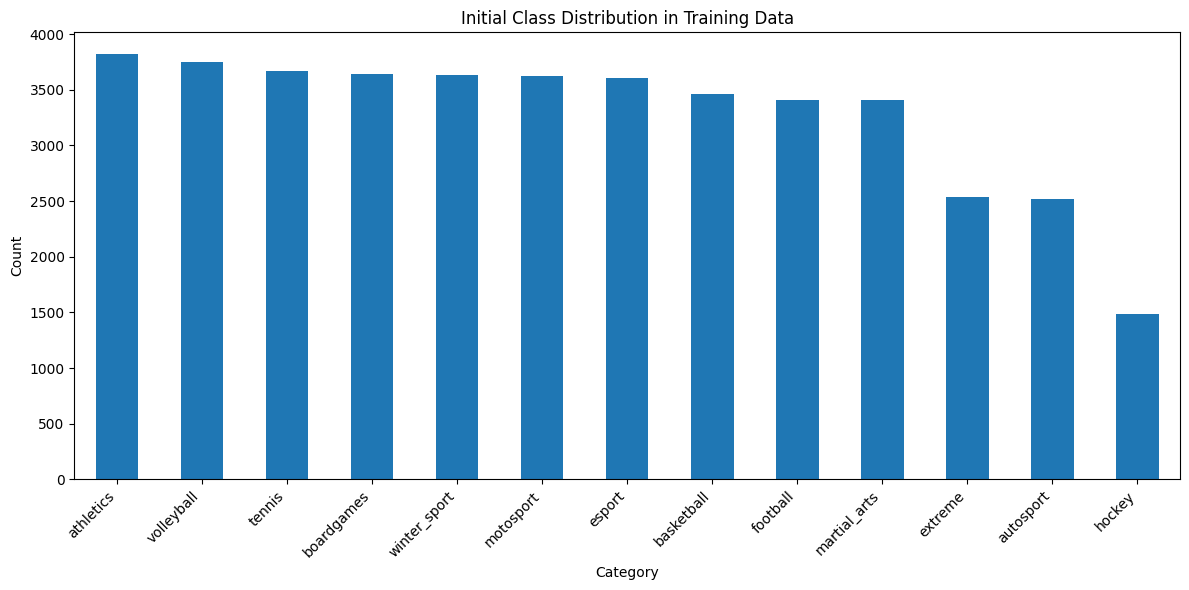

In [ ]:
import matplotlib.pyplot as plt

y_train_categories = le.inverse_transform(y_train)

class_counts = pd.Series(y_train_categories).value_counts()

plt.figure(figsize=(12, 6))
class_counts.plot(kind='bar')
plt.title('Initial Class Distribution in Training Data')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

TEXT_COL = "text"
LABEL_COL = "category"

le = LabelEncoder()
y = le.fit_transform(df[LABEL_COL].astype(str))
X = df[TEXT_COL].astype(str)

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=RANDOM_STATE)

X_train_resampled, y_train_resampled = rus.fit_resample(X_train.to_frame(), y_train)

print(pd.Series(le.inverse_transform(y_train_resampled)).value_counts())

athletics       1481
autosport       1481
basketball      1481
boardgames      1481
esport          1481
extreme         1481
football        1481
hockey          1481
martial_arts    1481
motosport       1481
tennis          1481
volleyball      1481
winter_sport    1481
Name: count, dtype: int64


еще сокращаю

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
import pandas as pd

MAX_SAMPLES_PER_CLASS = 600

class_counts = pd.Series(y_train).value_counts()

sampling_strategy = {
    cls: min(cnt, MAX_SAMPLES_PER_CLASS)
    for cls, cnt in class_counts.items()
}

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_train_resampled, y_train_resampled = rus.fit_resample(
    X_train.to_frame(), y_train
)

print(pd.Series(y_train_resampled).value_counts())


0     600
1     600
2     600
3     600
4     600
5     600
6     600
7     600
8     600
9     600
10    600
11    600
12    600
Name: count, dtype: int64
